# Gemini vs OpenAI — Stance Classification Accuracy Comparison

This notebook compares two LLM models (Gemini 3.5 Pro and OpenAI) on the same 50 manually-labeled FERC public comments.  
Both models used an identical prompt to classify each comment's stance toward an energy project.

**Files required:**
- `Gemini-new-check-capstone.xlsx` — Gemini results
- `Clean_Accuracy_Test_Capstone.xlsx` — OpenAI results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BLUE = '#3B82F6'   # Gemini
GREEN = '#10B981'  # OpenAI
GRAY = '#94A3B8'

## 1. Load and inspect data

In [2]:
# ── CONFIG: sections 1–9 ─────────────────────────────────────────────────────
GEMINI_PATH    = 'Gemiiii.xlsx'
OPENAI_PATH    = 'openai 4.0 mini.xlsx'
SHEET_COMMENTS = 'Comments and Stances'
SHEET_ACCURACY = 'Accuracy Table'
MODEL_A_NAME   = 'Gemini 3 Flash'
MODEL_B_NAME   = 'GPT-4o Mini'
# ─────────────────────────────────────────────────────────────────────────────

g_comments = pd.read_excel(GEMINI_PATH, sheet_name=SHEET_COMMENTS)
o_comments = pd.read_excel(OPENAI_PATH, sheet_name=SHEET_COMMENTS)

g_accuracy = pd.read_excel(GEMINI_PATH, sheet_name=SHEET_ACCURACY)
o_accuracy = pd.read_excel(OPENAI_PATH, sheet_name=SHEET_ACCURACY)

print(f'{MODEL_A_NAME} file: {len(g_comments)} comments')
print(f'{MODEL_B_NAME} file: {len(o_comments)} comments')
print(f'Same comment IDs: {set(g_comments["ID"]) == set(o_comments["ID"])}')
print()
g_comments.head(3)

Gemini 3 Flash file: 50 comments
GPT-4o Mini file: 50 comments
Same comment IDs: True



,ID,Text,Stance,LLM Stance,Match?
0,20110610-5012,I am opposed to any project that would affect ...,Oppose,oppose,1
1,20100927-5006,"The flow plan on the McCloud project, as endor...",Support,Support with Changes,0
2,20100929-5000,The McCloud is a really important river for fi...,Oppose,oppose,1


## 2. Build per-category accuracy comparison

In [3]:
# Normalize LLM stance labels to title case for matching
def normalize_stance(s):
    s = str(s).strip().lower()
    mapping = {
        'oppose': 'Oppose',
        'support': 'Support',
        'support with changes': 'Support with Changes',
        'support_with_major_changes': 'Support with Changes',
        'neutral': 'Neutral',
        'neutral_informative': 'Neutral',
    }
    return mapping.get(s, s.title())

g_comments['LLM_norm'] = g_comments['LLM Stance'].apply(normalize_stance)
o_comments['LLM_norm'] = o_comments['LLM Stance'].apply(normalize_stance)

# Per-category accuracy
categories = ['Support', 'Support with Changes', 'Oppose', 'Neutral']

rows = []
for cat in categories:
    g_mask = g_comments['Stance'] == cat
    o_mask = o_comments['Stance'] == cat
    g_total = g_mask.sum()
    o_total = o_mask.sum()
    g_correct = (g_comments.loc[g_mask, 'Match?'] == 1).sum()
    o_correct = (o_comments.loc[o_mask, 'Match?'] == 1).sum()
    rows.append({
        'Category': cat,
        'Total': g_total,
        'Gemini correct': g_correct,
        'Gemini accuracy': g_correct / g_total if g_total else 0,
        'OpenAI correct': o_correct,
        'OpenAI accuracy': o_correct / o_total if o_total else 0,
    })

# Totals row
g_total_all = len(g_comments)
o_total_all = len(o_comments)
g_correct_all = (g_comments['Match?'] == 1).sum()
o_correct_all = (o_comments['Match?'] == 1).sum()
rows.append({
    'Category': 'TOTAL',
    'Total': g_total_all,
    'Gemini correct': g_correct_all,
    'Gemini accuracy': g_correct_all / g_total_all,
    'OpenAI correct': o_correct_all,
    'OpenAI accuracy': o_correct_all / o_total_all,
})

comparison = pd.DataFrame(rows)
comparison['Difference'] = comparison['Gemini accuracy'] - comparison['OpenAI accuracy']
comparison['Winner'] = comparison['Difference'].apply(
    lambda d: MODEL_A_NAME if d > 0.01 else (MODEL_B_NAME if d < -0.01 else 'Tie')
)

# Display formatted
display_df = comparison.rename(columns={
    'Gemini correct':  f'{MODEL_A_NAME} correct',
    'Gemini accuracy': f'{MODEL_A_NAME} accuracy',
    'OpenAI correct':  f'{MODEL_B_NAME} correct',
    'OpenAI accuracy': f'{MODEL_B_NAME} accuracy',
}).copy()
for col in [f'{MODEL_A_NAME} accuracy', f'{MODEL_B_NAME} accuracy', 'Difference']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.1%}')
display_df

,Category,Total,Gemini 3 Flash correct,Gemini 3 Flash accuracy,GPT-4o Mini correct,GPT-4o Mini accuracy,Difference,Winner
0,Support,11,10,90.9%,7,63.6%,27.3%,Gemini 3 Flash
1,Support with Changes,8,5,62.5%,7,87.5%,-25.0%,GPT-4o Mini
2,Oppose,30,28,93.3%,27,90.0%,3.3%,Gemini 3 Flash
3,Neutral,1,0,0.0%,1,100.0%,-100.0%,GPT-4o Mini
4,TOTAL,50,43,86.0%,42,84.0%,2.0%,Gemini 3 Flash


## 3. Accuracy by stance category

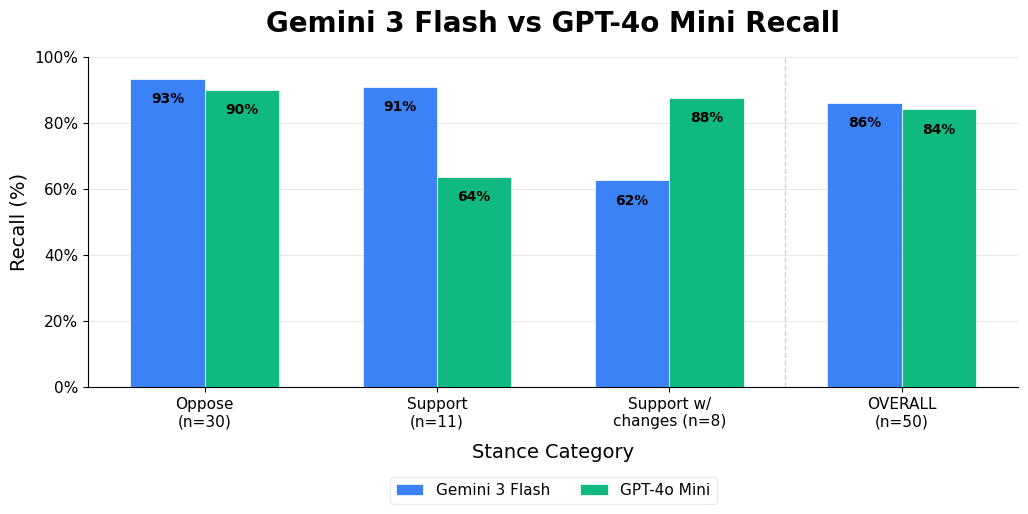

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.5))
cat_labels = ['Oppose\n(n=30)', 'Support\n(n=11)', 'Support w/\nchanges (n=8)', 'OVERALL\n(n=50)']
x = np.arange(len(cat_labels))
width = 0.32

gemini_all = list(comparison.loc[comparison['Category'] != 'TOTAL', 'Gemini accuracy'].values)
openai_all = list(comparison.loc[comparison['Category'] != 'TOTAL', 'OpenAI accuracy'].values)

# Reorder: Oppose (idx 2), Support (idx 0), SWC (idx 1), then OVERALL
gemini_acc = [gemini_all[2], gemini_all[0], gemini_all[1]] + [g_correct_all / g_total_all]
openai_acc = [openai_all[2], openai_all[0], openai_all[1]] + [o_correct_all / o_total_all]

bars1 = ax.bar(
    x - width/2,
    [a * 100 for a in gemini_acc],
    width,
    label=MODEL_A_NAME,
    color=BLUE,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)
bars2 = ax.bar(
    x + width/2,
    [a * 100 for a in openai_acc],
    width,
    label=MODEL_B_NAME,
    color=GREEN,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        y = max(h - 4, 2)
        ax.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f'{h:.0f}%',
            ha='center',
            va='top',
            fontsize=10,
            fontweight='bold',
            color='black'
        )
ax.axvline(x=2.5, color='#CBD5E1', linestyle='--', linewidth=1, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, fontsize=11)
ax.set_xlabel('Stance Category', fontsize=14, labelpad=10)
ax.set_ylabel('Recall (%)', fontsize=14)
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title(
    f'{MODEL_A_NAME} vs {MODEL_B_NAME} Recall',
    fontsize=20,
    fontweight='bold',
    pad=18
)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=True,
    edgecolor='#E2E8F0',
    fontsize=11,
    handlelength=1.8,
)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.subplots_adjust(bottom=0.28)
plt.savefig('accuracy_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Error analysis — what did each model get wrong?

In [5]:
# Collect misclassifications
g_pred_col = f'{MODEL_A_NAME} predicted'
o_pred_col = f'{MODEL_B_NAME} predicted'

g_errors = g_comments[g_comments['Match?'] == 0][['ID', 'Stance', 'LLM_norm']].copy()
g_errors.columns = ['ID', 'True stance', g_pred_col]
g_errors['Error type'] = g_errors['True stance'] + ' → ' + g_errors[g_pred_col]

o_errors = o_comments[o_comments['Match?'] == 0][['ID', 'Stance', 'LLM_norm']].copy()
o_errors.columns = ['ID', 'True stance', o_pred_col]
o_errors['Error type'] = o_errors['True stance'] + ' → ' + o_errors[o_pred_col]

print(f'{MODEL_A_NAME} errors: {len(g_errors)}')
print(f'{MODEL_B_NAME} errors: {len(o_errors)}')
print(f'Both got wrong: {set(g_errors["ID"]) & set(o_errors["ID"])}')
print()

print(f'── {MODEL_A_NAME} misclassifications ──')
display(g_errors[['ID', 'True stance', g_pred_col]].reset_index(drop=True))

print(f'\n── {MODEL_B_NAME} misclassifications ──')
display(o_errors[['ID', 'True stance', o_pred_col]].reset_index(drop=True))

Gemini 3 Flash errors: 7
GPT-4o Mini errors: 8
Both got wrong: {'20210510-5000', '20100927-5006'}

── Gemini 3 Flash misclassifications ──


,ID,True stance,Gemini 3 Flash predicted
0,20100927-5006,Support,Support with Changes
1,20171205-5061,Support with Changes,Oppose
2,20140821-5023,Support with Changes,Oppose
3,20230505-5000,Oppose,Error
4,20100114-5010,Oppose,Support with Changes
5,20210510-5000,Support with Changes,Oppose
6,20110825-5036,Neutral,Support with Changes



── GPT-4o Mini misclassifications ──


,ID,True stance,GPT-4o Mini predicted
0,20100927-5006,Support,Support with Changes
1,20100929-5000,Oppose,Support with Changes
2,20200831-5001,Support,Support with Changes
3,20240531-5076,Oppose,Support with Changes
4,20130805-5027,Support,Support with Changes
5,20210510-5000,Support with Changes,Oppose
6,20111201-5217,Oppose,Support with Changes
7,20200629-5192,Support,Oppose


## 5. Error pattern comparison

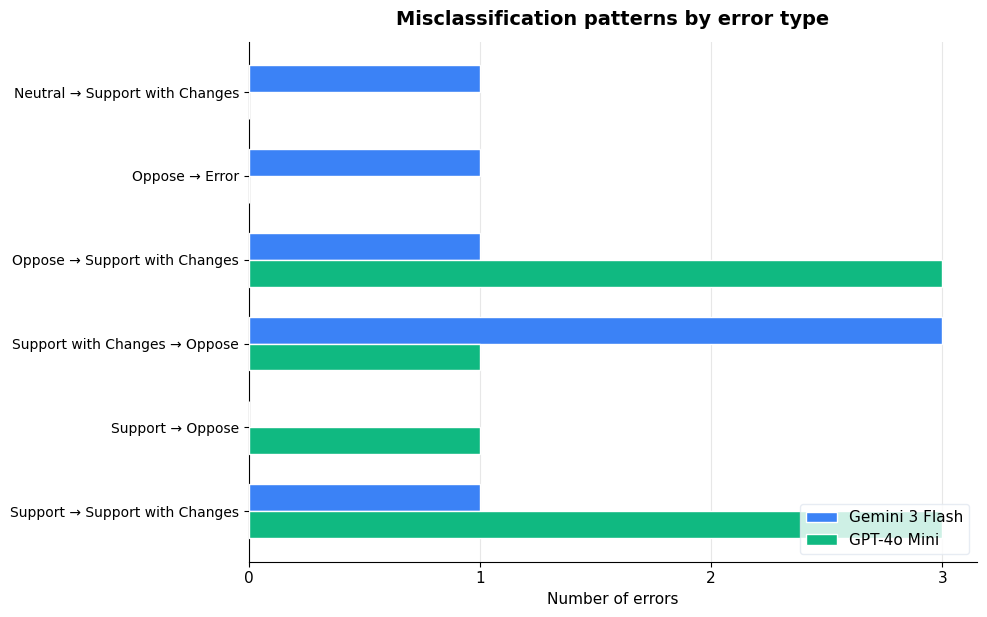

In [6]:
# Count error types for each model
g_err_counts = g_errors['Error type'].value_counts()
o_err_counts = o_errors['Error type'].value_counts()

all_err_types = sorted(set(g_err_counts.index) | set(o_err_counts.index))

g_vals = [g_err_counts.get(t, 0) for t in all_err_types]
o_vals = [o_err_counts.get(t, 0) for t in all_err_types]

fig, ax = plt.subplots(figsize=(10, max(4, len(all_err_types) * 0.8 + 1.5)))

y = np.arange(len(all_err_types))
height = 0.32

ax.barh(y - height/2, g_vals, height, label=MODEL_A_NAME, color=BLUE, edgecolor='white', zorder=3)
ax.barh(y + height/2, o_vals, height, label=MODEL_B_NAME, color=GREEN, edgecolor='white', zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(all_err_types, fontsize=10)
ax.set_xlabel('Number of errors', fontsize=11)
ax.set_title('Misclassification patterns by error type', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', frameon=True, edgecolor='#E2E8F0')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('error_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Where each model's errors concentrate

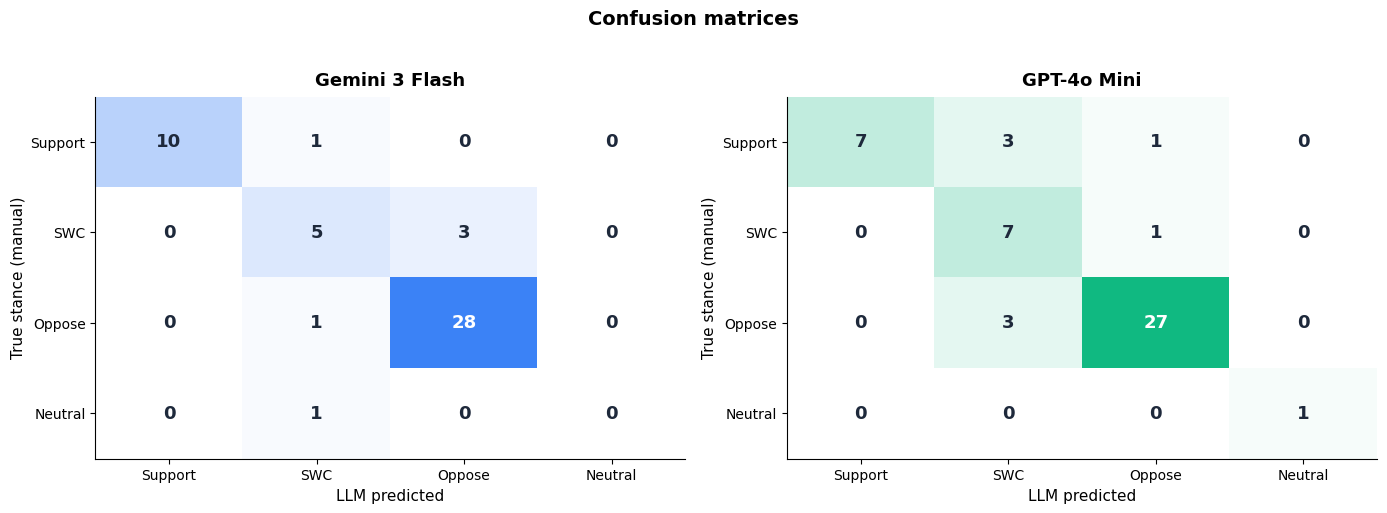

In [7]:
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name, color in [
    (axes[0], g_comments, MODEL_A_NAME, BLUE),
    (axes[1], o_comments, MODEL_B_NAME, GREEN),
]:
    cats_order = ['Support', 'Support with Changes', 'Oppose', 'Neutral']
    ct = pd.crosstab(
        df['Stance'].astype(pd.CategoricalDtype(cats_order, ordered=True)),
        df['LLM_norm'].astype(pd.CategoricalDtype(cats_order, ordered=True)),
        dropna=False
    ).reindex(index=cats_order, columns=cats_order, fill_value=0)

    cmap = LinearSegmentedColormap.from_list('custom', ['#FFFFFF', color], N=256)
    im = ax.imshow(ct.values, cmap=cmap, aspect='auto', vmin=0)

    for i in range(len(cats_order)):
        for j in range(len(cats_order)):
            val = ct.values[i, j]
            text_color = 'white' if val > ct.values.max() * 0.6 else '#1E293B'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=13, fontweight='bold', color=text_color)

    short_labels = ['Support', 'SWC', 'Oppose', 'Neutral']
    ax.set_xticks(range(len(cats_order)))
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.set_yticks(range(len(cats_order)))
    ax.set_yticklabels(short_labels, fontsize=10)
    ax.set_xlabel('LLM predicted', fontsize=11)
    ax.set_ylabel('True stance (manual)', fontsize=11)
    ax.set_title(name, fontsize=13, fontweight='bold', pad=8)

fig.suptitle('Confusion matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Side-by-side: every comment, both models

In [8]:
# Merge on ID to compare comment by comment
a_pred = f'{MODEL_A_NAME} prediction'
a_corr = f'{MODEL_A_NAME} correct'
b_pred = f'{MODEL_B_NAME} prediction'
b_corr = f'{MODEL_B_NAME} correct'

merged = g_comments[['ID', 'Stance', 'LLM_norm', 'Match?']].merge(
    o_comments[['ID', 'LLM_norm', 'Match?']],
    on='ID', suffixes=('_a', '_b')
)
merged.columns = ['ID', 'True stance', a_pred, a_corr, b_pred, b_corr]

merged['Both correct']            = (merged[a_corr] == 1) & (merged[b_corr] == 1)
merged['Both wrong']              = (merged[a_corr] == 0) & (merged[b_corr] == 0)
merged[f'Only {MODEL_A_NAME} wrong'] = (merged[a_corr] == 0) & (merged[b_corr] == 1)
merged[f'Only {MODEL_B_NAME} wrong'] = (merged[a_corr] == 1) & (merged[b_corr] == 0)

print(f"Both correct:               {merged['Both correct'].sum()} / {len(merged)}")
print(f"Both wrong:                 {merged['Both wrong'].sum()} / {len(merged)}")
print(f"Only {MODEL_A_NAME} wrong:  {merged[f'Only {MODEL_A_NAME} wrong'].sum()} / {len(merged)}")
print(f"Only {MODEL_B_NAME} wrong:  {merged[f'Only {MODEL_B_NAME} wrong'].sum()} / {len(merged)}")

# Show disagreements
disagreements = merged[
    (merged[a_corr] != merged[b_corr]) |
    (merged['Both wrong'])
].sort_values('True stance')

print(f'\n── Comments where models disagreed or both failed ({len(disagreements)}) ──')
disagreements[['ID', 'True stance', a_pred, a_corr, b_pred, b_corr]]

Both correct:               37 / 50
Both wrong:                 2 / 50
Only Gemini 3 Flash wrong:  5 / 50
Only GPT-4o Mini wrong:  6 / 50

── Comments where models disagreed or both failed (13) ──


,ID,True stance,Gemini 3 Flash prediction,Gemini 3 Flash correct,GPT-4o Mini prediction,GPT-4o Mini correct
45,20110825-5036,Neutral,Support with Changes,0,Neutral,1
2,20100929-5000,Oppose,Oppose,1,Support with Changes,0
20,20230505-5000,Oppose,Error,0,Oppose,1
26,20240531-5076,Oppose,Oppose,1,Support with Changes,0
35,20100114-5010,Oppose,Support with Changes,0,Oppose,1
42,20111201-5217,Oppose,Oppose,1,Support with Changes,0
1,20100927-5006,Support,Support with Changes,0,Support with Changes,0
16,20200831-5001,Support,Support,1,Support with Changes,0
39,20130805-5027,Support,Support,1,Support with Changes,0
46,20200629-5192,Support,Support,1,Oppose,0


## 8. Error overlap

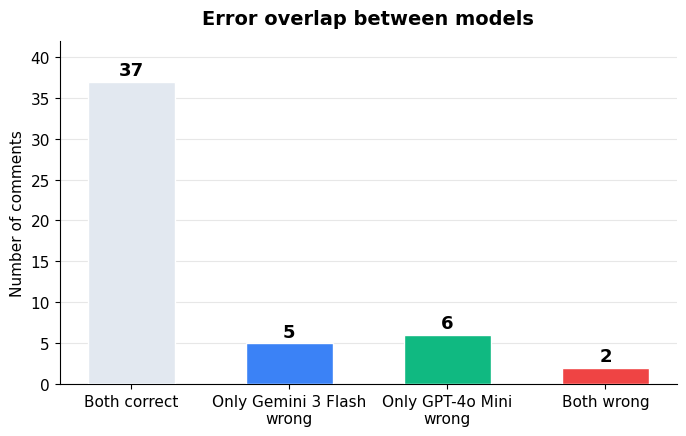

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

both_wrong   = merged['Both wrong'].sum()
only_a       = merged[f'Only {MODEL_A_NAME} wrong'].sum()
only_b       = merged[f'Only {MODEL_B_NAME} wrong'].sum()
both_correct = merged['Both correct'].sum()

labels = ['Both correct', f'Only {MODEL_A_NAME}\nwrong', f'Only {MODEL_B_NAME}\nwrong', 'Both wrong']
values = [both_correct, only_a, only_b, both_wrong]
colors = ['#E2E8F0', BLUE, GREEN, '#EF4444']

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1, width=0.55, zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Number of comments', fontsize=11)
ax.set_title('Error overlap between models', fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(0, max(values) + 5)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('error_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

| Metric | Gemini 3 Flash | GPT-4o Mini |
|--------|---------------|-------------|
| **Overall accuracy** | 86% (43/50) | 84% (42/50) |
| **Support** | 91% (10/11) | 64% (7/11) |
| **Support with Changes** | 63% (5/8) | 88% (7/8) |
| **Oppose** | 93% (28/30) | 90% (27/30) |
| **Neutral** | 0% (0/1) | 100% (1/1) |

### Key findings

- **Gemini** achieves high accuracy on Oppose and Support — the two dominant categories (41/50 comments).  
  Its errors are concentrated in "Support with Changes" (3/7 errors), where it tends to reclassify as Oppose.

- **GPT-4o Mini** handles the nuanced "Support with Changes" category better (88% vs 63%), but over-applies the SWC label —  
  misclassifying clear Support and Oppose comments as conditional. It also misclassifies 4/11 Support comments.

- Only **2 comments** were misclassified by both models, suggesting their error patterns are largely complementary.

- **Gemini was selected for scaling** because its error pattern is safer for the FERC dataset:  
  correctly identifying clear support and opposition matters more than catching the rare conditional-support edge case.

- **Switch from Pro to Flash**: With a heavily engineered prompt (decision tree, self-correction protocol, structured JSON output),  
  the lighter Flash model can follow the same instructions at lower latency and cost — critical for processing thousands of PDFs.

---
## 10. New 240-Sample Analysis — Gemini · GPT · Claude

Using `sample_240_new_models_prompt_2.xlsx`. Ground truth = Hand Coded sheet (180 matched rows).  
Labels: **Oppose · Neutral · Support · Support with Changes**

In [ ]:
# ── CONFIG: section 10 (pro models, 240-sample) ───────────────────────────────
XLSX_PRO        = '240_pro_models_prompt_2.xlsx'
PRO_SHEET_TRUTH = 'Hand Coded'
PRO_SHEET_A     = 'gemini-3.1-pro-preview'
PRO_SHEET_B     = 'gpt-5.4'
PRO_SHEET_C     = 'claude-opus-4-6'
PRO_A_NAME      = 'Gemini 3.1 Pro'
PRO_B_NAME      = 'GPT-5.4'
PRO_C_NAME      = 'Claude Opus 4.6'
# ─────────────────────────────────────────────────────────────────────────────

In [11]:
# ── Section 10: Load 240-sample data ─────────────────────────────────────────
df_hand   = pd.read_excel(XLSX_PRO, sheet_name=PRO_SHEET_TRUTH)
df_gemini = pd.read_excel(XLSX_PRO, sheet_name=PRO_SHEET_A)
df_gpt    = pd.read_excel(XLSX_PRO, sheet_name=PRO_SHEET_B)
df_claude = pd.read_excel(XLSX_PRO, sheet_name=PRO_SHEET_C)

LABEL_ORDER = ['Oppose', 'Neutral', 'Support', 'Support with Changes']

def norm_label(s):
    s = str(s).strip()
    t = s.lower().replace('_', ' ').replace('-', ' ')
    if 'support with change' in t:
        return 'Support with Changes'
    if t == 'support':
        return 'Support'
    if t == 'neutral':
        return 'Neutral'
    if t in ('oppose', 'opposing', 'opposed', 'opposition'):
        return 'Oppose'
    return s

df_hand['true_label'] = df_hand['llm_support_label'].apply(norm_label)

for df, col in [(df_gemini, 'llm_support_label'),
                (df_gpt,    'llm_support_label'),
                (df_claude, 'llm_support_label')]:
    df['pred_label'] = df[col].apply(norm_label)

def merge_with_truth(df_model, name):
    m = df_hand[['pdf_id', 'true_label']].merge(
        df_model[['pdf_id', 'pred_label']], on='pdf_id', how='inner'
    )
    m['model'] = name
    return m

m_gemini = merge_with_truth(df_gemini, PRO_A_NAME)
m_gpt    = merge_with_truth(df_gpt,    PRO_B_NAME)
m_claude = merge_with_truth(df_claude, PRO_C_NAME)

print(f"Matched rows — {PRO_A_NAME}: {len(m_gemini)}, {PRO_B_NAME}: {len(m_gpt)}, {PRO_C_NAME}: {len(m_claude)}")
print("\nTrue label counts (ground truth):")
print(m_gemini['true_label'].value_counts())

Matched rows — Gemini 3.1 Pro: 234, GPT-5.4: 234, Claude Opus 4.6: 234

True label counts (ground truth):
true_label
Oppose                  101
Neutral                  47
Support                  47
Support with Changes     39
Name: count, dtype: int64


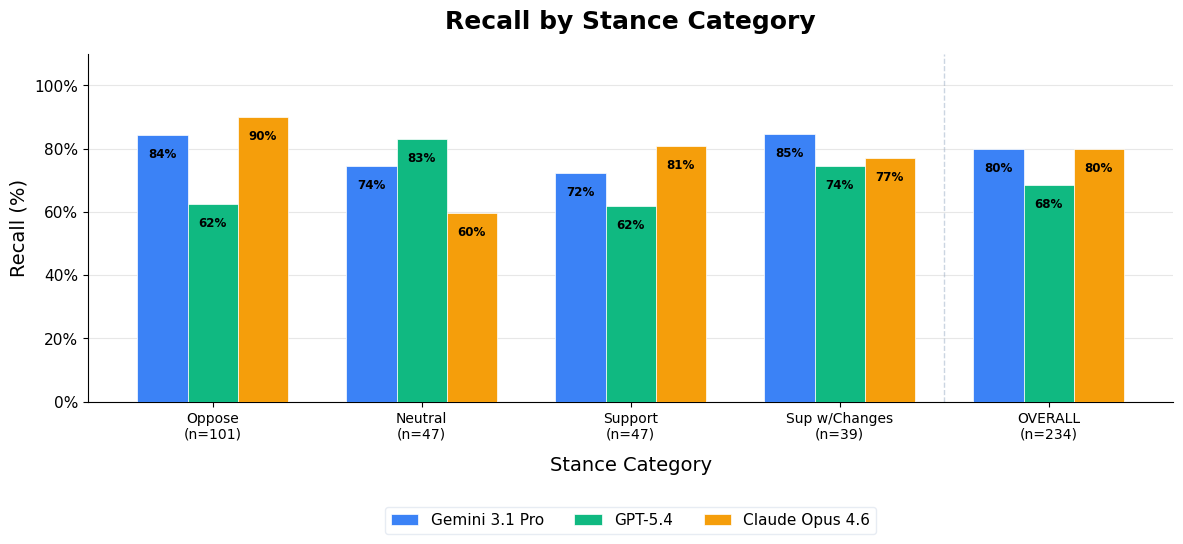

In [12]:
# ── Section 10: Recall bar chart (3 models) ──────────────────────────────────
ORANGE = '#F59E0B'   # Claude

def per_class_recall(m):
    recalls = {}
    for lbl in LABEL_ORDER:
        true_pos = ((m['true_label'] == lbl) & (m['pred_label'] == lbl)).sum()
        total    = (m['true_label'] == lbl).sum()
        recalls[lbl] = true_pos / total if total > 0 else 0.0
    overall = (m['true_label'] == m['pred_label']).sum() / len(m)
    return recalls, overall

g_rec, g_ov = per_class_recall(m_gemini)
o_rec, o_ov = per_class_recall(m_gpt)
c_rec, c_ov = per_class_recall(m_claude)

n_counts = {lbl: (m_gemini['true_label'] == lbl).sum() for lbl in LABEL_ORDER}
n_total  = len(m_gemini)

cat_labels_240 = [
    f'Oppose\n(n={n_counts["Oppose"]})',
    f'Neutral\n(n={n_counts["Neutral"]})',
    f'Support\n(n={n_counts["Support"]})',
    f'Sup w/Changes\n(n={n_counts["Support with Changes"]})',
    f'OVERALL\n(n={n_total})',
]

gemini_vals = [g_rec[l] for l in LABEL_ORDER] + [g_ov]
gpt_vals    = [o_rec[l] for l in LABEL_ORDER] + [o_ov]
claude_vals = [c_rec[l] for l in LABEL_ORDER] + [c_ov]

x = np.arange(len(cat_labels_240))
width = 0.24

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width,     [v*100 for v in gemini_vals], width, label=PRO_A_NAME, color=BLUE,   edgecolor='white', linewidth=0.5, zorder=3)
bars2 = ax.bar(x,             [v*100 for v in gpt_vals],    width, label=PRO_B_NAME, color=GREEN,  edgecolor='white', linewidth=0.5, zorder=3)
bars3 = ax.bar(x + width,     [v*100 for v in claude_vals], width, label=PRO_C_NAME, color=ORANGE, edgecolor='white', linewidth=0.5, zorder=3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            max(h - 4, 2),
            f'{h:.0f}%',
            ha='center', va='top',
            fontsize=8.5, fontweight='bold', color='black'
        )

ax.axvline(x=3.5, color='#CBD5E1', linestyle='--', linewidth=1, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels_240, fontsize=10)
ax.set_xlabel('Stance Category', fontsize=14, labelpad=10)
ax.set_ylabel('Recall (%)', fontsize=14)
ax.set_ylim(0, 110)
ax.set_yticks(np.arange(0, 101, 20))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title('Recall by Stance Category', fontsize=18, fontweight='bold', pad=18)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=3,
          frameon=True, edgecolor='#E2E8F0', fontsize=11, handlelength=1.8)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.subplots_adjust(bottom=0.30)
plt.savefig('recall_240_sample_3models.png', dpi=150, bbox_inches='tight')
plt.show()

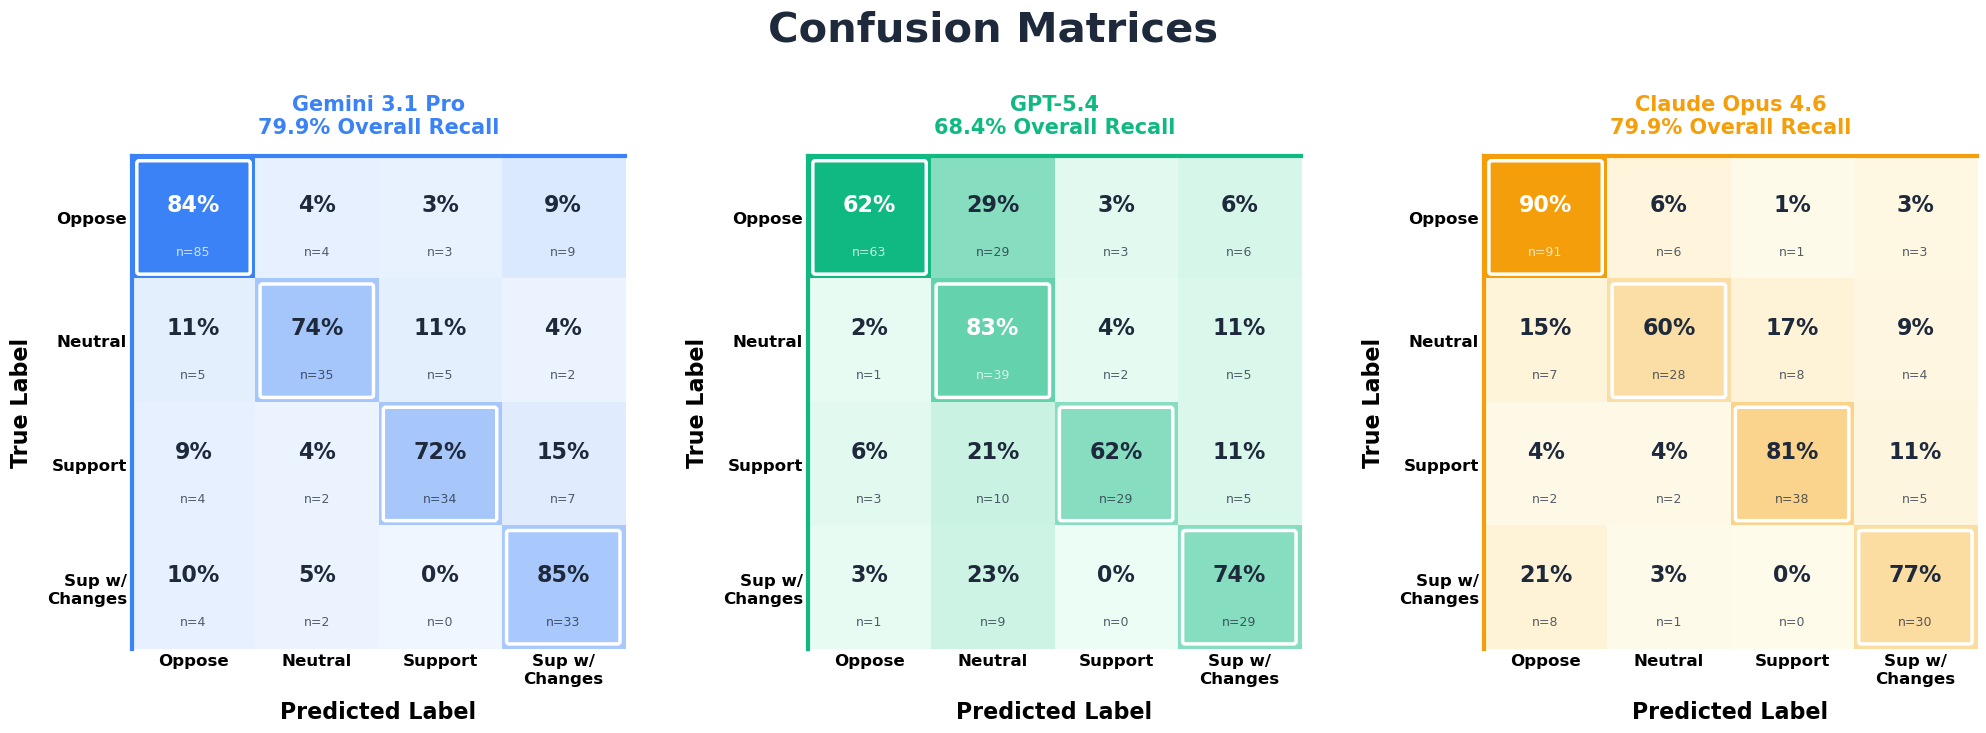

In [13]:
# ── Section 10: Confusion matrices (3 models) — slideshow-ready ───────────────
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import confusion_matrix

ORANGE = '#F59E0B'   # Claude

MODEL_CFG = {
    PRO_A_NAME: {'df': None, 'color': BLUE,   'cmap': LinearSegmentedColormap.from_list('', ['#EFF6FF', '#3B82F6'])},
    PRO_B_NAME: {'df': None, 'color': GREEN,  'cmap': LinearSegmentedColormap.from_list('', ['#ECFDF5', '#10B981'])},
    PRO_C_NAME: {'df': None, 'color': ORANGE, 'cmap': LinearSegmentedColormap.from_list('', ['#FFFBEB', '#F59E0B'])},
}
MODEL_CFG[PRO_A_NAME]['df']  = m_gemini
MODEL_CFG[PRO_B_NAME]['df']  = m_gpt
MODEL_CFG[PRO_C_NAME]['df']  = m_claude

tick_labels = ['Oppose', 'Neutral', 'Support', 'Sup w/\nChanges']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('white')

for ax, (name, cfg) in zip(axes, MODEL_CFG.items()):
    m   = cfg['df']
    clr = cfg['color']
    cmap = cfg['cmap']

    cm = confusion_matrix(m['true_label'], m['pred_label'], labels=LABEL_ORDER)
    n  = len(LABEL_ORDER)

    ax.imshow(cm, aspect='equal', cmap=cmap, vmin=0, vmax=cm.max())
    ax.set_facecolor('white')

    for i in range(n):
        for j in range(n):
            v         = cm[i, j]
            total_row = cm[i].sum()
            pct       = v / total_row * 100 if total_row > 0 else 0
            is_diag   = (i == j)
            intensity = v / cm.max() if cm.max() > 0 else 0
            txt_color = 'white' if intensity > 0.55 else '#1E293B'

            if is_diag:
                ax.add_patch(FancyBboxPatch(
                    (j - 0.44, i - 0.44), 0.88, 0.88,
                    boxstyle='round,pad=0.02',
                    linewidth=2.5, edgecolor='white', facecolor='none', zorder=3
                ))

            ax.text(j, i - 0.1, f'{pct:.0f}%',
                    ha='center', va='center', fontsize=16,
                    fontweight='bold', color=txt_color, zorder=4)
            ax.text(j, i + 0.28, f'n={v}',
                    ha='center', va='center', fontsize=9,
                    color=txt_color, alpha=0.75, zorder=4)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tick_labels, fontsize=12, fontweight='bold')
    ax.set_yticklabels(tick_labels, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=16, labelpad=10, fontweight='bold')
    ax.set_ylabel('True Label',      fontsize=16, labelpad=10, fontweight='bold')
    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)
    for side in ['top', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(3)
        ax.spines[side].set_color(clr)

    overall_acc = (m['true_label'] == m['pred_label']).mean() * 100
    ax.set_title(
        f'{name}\n{overall_acc:.1f}% Overall Recall',
        fontsize=15, fontweight='bold', color=clr, pad=16
    )

plt.suptitle(
    'Confusion Matrices',
    fontsize=30, fontweight='bold', color='#1E293B', y=1.03
)
plt.tight_layout(w_pad=4)
plt.savefig('confusion_matrices_240_sample.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

---
## 11. Flash Models 240-Sample Analysis — Gemini · GPT · Claude

Using `sample_240_flash_models.xlsx`. Ground truth = Hand Coded sheet.  
Labels: **Oppose · Neutral · Support · Support with Changes**

In [14]:
# ── CONFIG: section 11 (fast models, 240-sample) ─────────────────────────────
XLSX_FAST        = 'sample_240_fast_models_prompt_4.xlsx'
FAST_SHEET_TRUTH = 'Hand Coded'
FAST_SHEET_A     = 'gemini-3.1-flash-lite-preview'
FAST_SHEET_B     = 'gpt-5.4-mini'
FAST_SHEET_C     = 'claude-sonnet-4-6'
FAST_A_NAME      = 'Gemini 3.1 Flash Lite'
FAST_B_NAME      = 'GPT-5.4 Mini'
FAST_C_NAME      = 'Claude Sonnet 4.6'
# ─────────────────────────────────────────────────────────────────────────────

In [15]:
# ── Section 11: Load 240-sample flash data ───────────────────────────────────
df_hand_f   = pd.read_excel(XLSX_FAST, sheet_name=FAST_SHEET_TRUTH)
df_gemini_f = pd.read_excel(XLSX_FAST, sheet_name=FAST_SHEET_A)
df_gpt_f    = pd.read_excel(XLSX_FAST, sheet_name=FAST_SHEET_B)
df_claude_f = pd.read_excel(XLSX_FAST, sheet_name=FAST_SHEET_C)

LABEL_ORDER = ['Oppose', 'Neutral', 'Support', 'Support with Changes']

df_hand_f['true_label'] = df_hand_f['llm_support_label'].apply(norm_label)

for df, col in [(df_gemini_f, 'llm_support_label'),
                (df_gpt_f,    'llm_support_label'),
                (df_claude_f, 'llm_support_label')]:
    df['pred_label'] = df[col].apply(norm_label)

def merge_with_truth_f(df_model, name):
    m = df_hand_f[['pdf_id', 'true_label']].merge(
        df_model[['pdf_id', 'pred_label']], on='pdf_id', how='inner'
    )
    m['model'] = name
    return m

m_gemini_f = merge_with_truth_f(df_gemini_f, FAST_A_NAME)
m_gpt_f    = merge_with_truth_f(df_gpt_f,    FAST_B_NAME)
m_claude_f = merge_with_truth_f(df_claude_f, FAST_C_NAME)

print(f"Matched rows — {FAST_A_NAME}: {len(m_gemini_f)}, {FAST_B_NAME}: {len(m_gpt_f)}, {FAST_C_NAME}: {len(m_claude_f)}")
print("True label counts (ground truth):")
print(m_gemini_f['true_label'].value_counts())

Matched rows — Gemini 3.1 Flash Lite: 234, GPT-5.4 Mini: 234, Claude Sonnet 4.6: 234
True label counts (ground truth):
true_label
Oppose                  101
Neutral                  47
Support                  47
Support with Changes     39
Name: count, dtype: int64


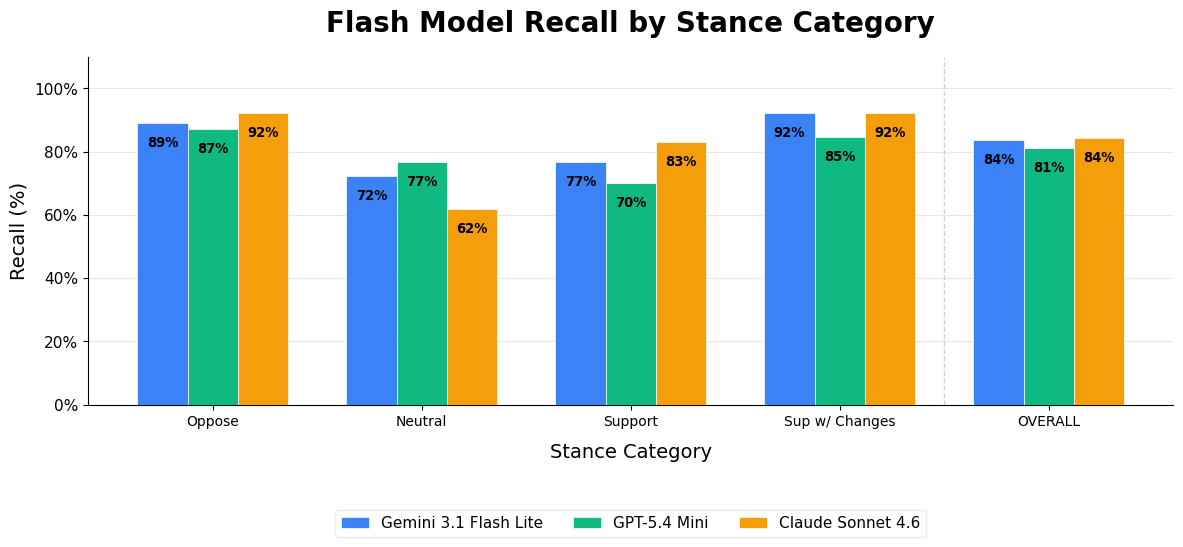

In [16]:
# ── Section 11: Recall bar chart (3 flash models) ────────────────────────────
ORANGE = '#F59E0B'   # Claude

def per_class_recall(m):
    recalls = {}
    for lbl in LABEL_ORDER:
        true_pos = ((m['true_label'] == lbl) & (m['pred_label'] == lbl)).sum()
        total    = (m['true_label'] == lbl).sum()
        recalls[lbl] = true_pos / total if total > 0 else 0.0
    overall = (m['true_label'] == m['pred_label']).sum() / len(m)
    return recalls, overall

g_rec_f, g_ov_f = per_class_recall(m_gemini_f)
o_rec_f, o_ov_f = per_class_recall(m_gpt_f)
c_rec_f, c_ov_f = per_class_recall(m_claude_f)

n_counts_f = {lbl: (m_gemini_f['true_label'] == lbl).sum() for lbl in LABEL_ORDER}
n_total_f  = len(m_gemini_f)

cat_labels_flash = ['Oppose', 'Neutral', 'Support', 'Sup w/ Changes', 'OVERALL']
gemini_vals_f = [g_rec_f[l] for l in LABEL_ORDER] + [g_ov_f]
gpt_vals_f    = [o_rec_f[l] for l in LABEL_ORDER] + [o_ov_f]
claude_vals_f = [c_rec_f[l] for l in LABEL_ORDER] + [c_ov_f]

x     = np.arange(len(cat_labels_flash))
width = 0.24

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, [v*100 for v in gemini_vals_f], width, label=FAST_A_NAME, color=BLUE,   edgecolor='white', linewidth=0.5, zorder=3)
bars2 = ax.bar(x,         [v*100 for v in gpt_vals_f],    width, label=FAST_B_NAME, color=GREEN,  edgecolor='white', linewidth=0.5, zorder=3)
bars3 = ax.bar(x + width, [v*100 for v in claude_vals_f], width, label=FAST_C_NAME, color=ORANGE, edgecolor='white', linewidth=0.5, zorder=3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            max(h - 4, 2),
            f'{h:.0f}%',
            ha='center', va='top',
            fontsize=9.5, fontweight='bold', color='black'
        )

ax.axvline(x=3.5, color='#CBD5E1', linestyle='--', linewidth=1, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels_flash, fontsize=10)
ax.set_xlabel('Stance Category', fontsize=14, labelpad=10)
ax.set_ylabel('Recall (%)', fontsize=14)
ax.set_ylim(0, 110)
ax.set_yticks(np.arange(0, 101, 20))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title('Flash Model Recall by Stance Category', fontsize=20, fontweight='bold', pad=18)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=3,
          frameon=True, edgecolor='#E2E8F0', fontsize=11, handlelength=1.8)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.subplots_adjust(bottom=0.30)
plt.savefig('recall_240_flash_models.png', dpi=150, bbox_inches='tight')
plt.show()

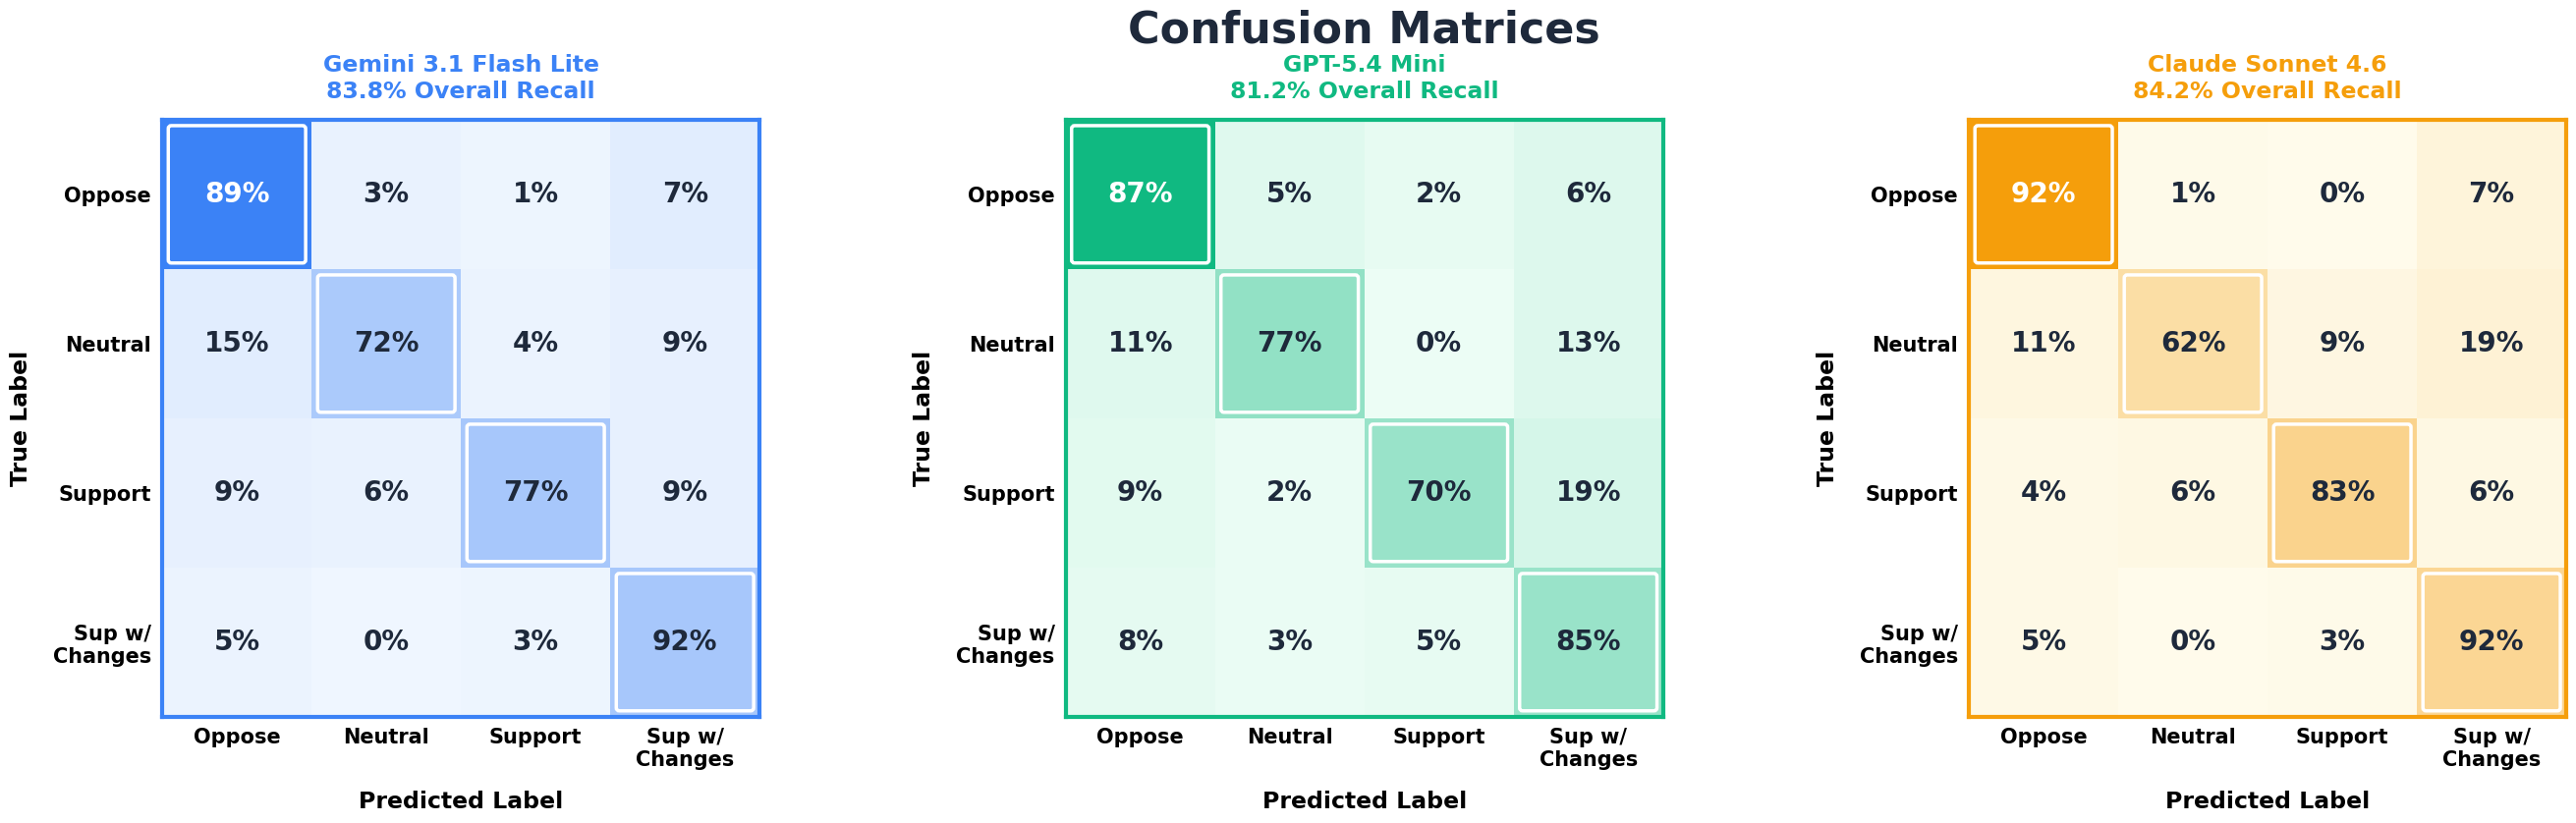

In [17]:
# ── Section 11: Confusion matrices (3 flash models) — slideshow-ready ──────────
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import confusion_matrix

ORANGE = '#F59E0B'   # Claude

MODEL_CFG_F = {
    FAST_A_NAME: {'df': None, 'color': BLUE,   'cmap': LinearSegmentedColormap.from_list('', ['#EFF6FF', '#3B82F6'])},
    FAST_B_NAME: {'df': None, 'color': GREEN,  'cmap': LinearSegmentedColormap.from_list('', ['#ECFDF5', '#10B981'])},
    FAST_C_NAME: {'df': None, 'color': ORANGE, 'cmap': LinearSegmentedColormap.from_list('', ['#FFFBEB', '#F59E0B'])},
}

MODEL_CFG_F[FAST_A_NAME]['df'] = m_gemini_f
MODEL_CFG_F[FAST_B_NAME]['df'] = m_gpt_f
MODEL_CFG_F[FAST_C_NAME]['df'] = m_claude_f

tick_labels = ['Oppose', 'Neutral', 'Support', 'Sup w/\nChanges']

fig, axes = plt.subplots(1, 3, figsize=(28, 8), constrained_layout=False)
fig.patch.set_facecolor('white')

for ax, (name, cfg) in zip(axes, MODEL_CFG_F.items()):
    m    = cfg['df']
    clr  = cfg['color']
    cmap = cfg['cmap']

    cm = confusion_matrix(m['true_label'], m['pred_label'], labels=LABEL_ORDER)
    n  = len(LABEL_ORDER)

    ax.imshow(cm, aspect='equal', cmap=cmap, vmin=0, vmax=cm.max())
    ax.set_facecolor('white')

    for i in range(n):
        for j in range(n):
            v         = cm[i, j]
            total_row = cm[i].sum()
            pct       = v / total_row * 100 if total_row > 0 else 0
            is_diag   = (i == j)
            intensity = v / cm.max() if cm.max() > 0 else 0
            txt_color = 'white' if intensity > 0.55 else '#1E293B'

            if is_diag:
                ax.add_patch(FancyBboxPatch(
                    (j - 0.44, i - 0.44), 0.88, 0.88,
                    boxstyle='round,pad=0.02',
                    linewidth=2.5, edgecolor='white', facecolor='none', zorder=3
                ))

            ax.text(j, i, f'{pct:.0f}%',
                    ha='center', va='center', fontsize=20,
                    fontweight='bold', color=txt_color, zorder=4)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tick_labels, fontsize=15, fontweight='bold')
    ax.set_yticklabels(tick_labels, fontsize=15, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=17, labelpad=15, fontweight='bold')
    ax.set_ylabel('True Label',      fontsize=17, labelpad=15, fontweight='bold')
    ax.tick_params(length=0, pad=8)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)
        spine.set_color(clr)

    overall_acc = (m['true_label'] == m['pred_label']).mean() * 100
    ax.set_title(
        f'{name}\n{overall_acc:.1f}% Overall Recall',
        fontsize=17, fontweight='bold', color=clr, pad=16
    )

plt.suptitle(
    'Confusion Matrices',
    fontsize=32, fontweight='bold', color='#1E293B', y=1.02
)
plt.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.12, wspace=0.35)
plt.savefig('confusion_matrices_240_flash.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

In [18]:
# ── Cell 1: Cohen's Kappa — Pro & Fast models ─────────────────────────────────
from sklearn.metrics import cohen_kappa_score

PRO_MODELS = {
    PRO_A_NAME: m_gemini,
    PRO_B_NAME: m_gpt,
    PRO_C_NAME: m_claude,
}

FAST_MODELS = {
    FAST_A_NAME: m_gemini_f,
    FAST_B_NAME: m_gpt_f,
    FAST_C_NAME: m_claude_f,
}

def kappa_row(name, df, tier):
    k_unweighted = cohen_kappa_score(df['true_label'], df['pred_label'])
    k_linear     = cohen_kappa_score(df['true_label'], df['pred_label'],
                                     labels=LABEL_ORDER, weights='linear')
    k_quadratic  = cohen_kappa_score(df['true_label'], df['pred_label'],
                                     labels=LABEL_ORDER, weights='quadratic')
    acc = (df['true_label'] == df['pred_label']).mean()
    return {
        'Tier': tier,
        'Model': name,
        'N': len(df),
        'Accuracy': round(acc, 3),
        "Cohen's κ": round(k_unweighted, 3),
        'Linear-weighted κ': round(k_linear, 3),
        'Quadratic-weighted κ': round(k_quadratic, 3),
    }

rows = []
for name, df in PRO_MODELS.items():
    rows.append(kappa_row(name, df, 'Pro'))
for name, df in FAST_MODELS.items():
    rows.append(kappa_row(name, df, 'Fast'))

kappa_df = pd.DataFrame(rows)
print('Cohen\u2019s Kappa — agreement with human labels (chance-corrected)')
print('=' * 80)
print(kappa_df.to_string(index=False))
print()
print('Note: weighted kappa gives partial credit for near-misses on the ordinal')
print('scale Oppose < Neutral < Support w/ Changes < Support.')

Cohen’s Kappa — agreement with human labels (chance-corrected)
Tier                 Model   N  Accuracy  Cohen's κ  Linear-weighted κ  Quadratic-weighted κ
 Pro        Gemini 3.1 Pro 234     0.799      0.717              0.718                 0.712
 Pro               GPT-5.4 234     0.684      0.572              0.623                 0.669
 Pro       Claude Opus 4.6 234     0.799      0.713              0.737                 0.744
Fast Gemini 3.1 Flash Lite 234     0.838      0.770              0.782                 0.787
Fast          GPT-5.4 Mini 234     0.812      0.735              0.750                 0.761
Fast     Claude Sonnet 4.6 234     0.842      0.776              0.782                 0.785

Note: weighted kappa gives partial credit for near-misses on the ordinal
scale Oppose < Neutral < Support w/ Changes < Support.


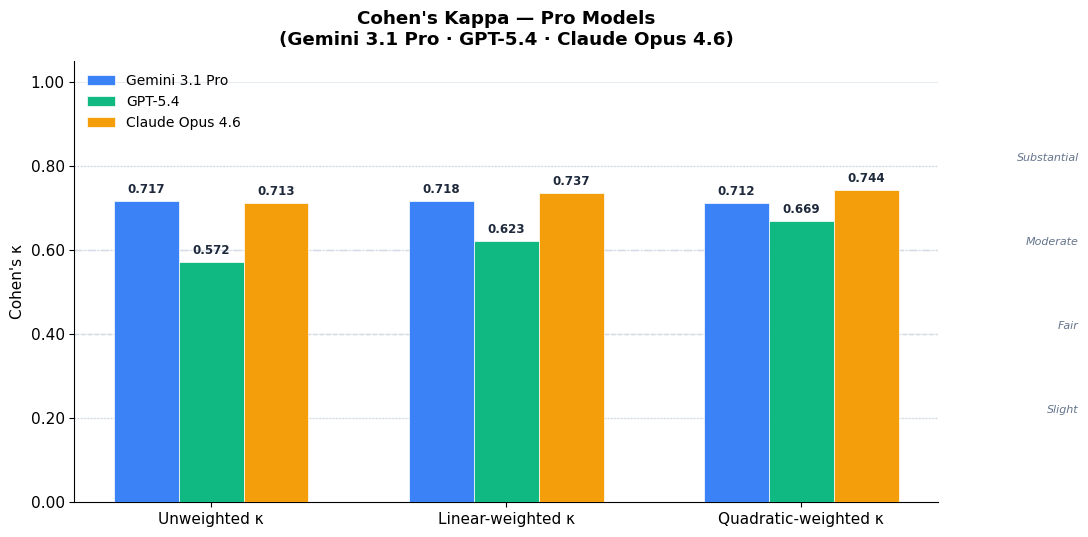

Saved cohens_kappa_pro_models.png


In [19]:
# ── Kappa visualization — Pro models ─────────────────────────────────────────
ORANGE = '#F59E0B'  # Claude

pro_kappa = kappa_df[kappa_df['Tier'] == 'Pro'].reset_index(drop=True)

kappa_metrics = ["Cohen's \u03ba", 'Linear-weighted \u03ba', 'Quadratic-weighted \u03ba']
kappa_labels  = ['Unweighted \u03ba', 'Linear-weighted \u03ba', 'Quadratic-weighted \u03ba']
pro_colors    = [BLUE, GREEN, ORANGE]

x     = np.arange(len(kappa_metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

n_models = len(pro_kappa)
for i, (_, row) in enumerate(pro_kappa.iterrows()):
    vals   = [row[m] for m in kappa_metrics]
    offset = (i - (n_models - 1) / 2) * width
    bars   = ax.bar(x + offset, vals, width, label=row['Model'],
                    color=pro_colors[i], edgecolor='white', linewidth=0.5, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                color='#1E293B')

# Landis-Koch tier reference lines
tiers = [(0.20, 'Slight', ':'), (0.40, 'Fair', '--'),
         (0.60, 'Moderate', '-.'), (0.80, 'Substantial', ':')]
for y, label, ls in tiers:
    ax.axhline(y, color='#94A3B8', linestyle=ls, linewidth=0.9, zorder=1)
    ax.text(len(kappa_metrics) - 0.06, y + 0.008, label,
            ha='right', va='bottom', fontsize=8, color='#64748B', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(kappa_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cohen's \u03ba", fontsize=11)
ax.set_title(f"Cohen's Kappa — Pro Models\n({PRO_A_NAME} · {PRO_B_NAME} · {PRO_C_NAME})",
             fontweight='bold', pad=12)
ax.legend(loc='upper left', frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', color='#E2E8F0', linewidth=0.6, zorder=0)

plt.tight_layout()
plt.savefig('cohens_kappa_pro_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved cohens_kappa_pro_models.png")

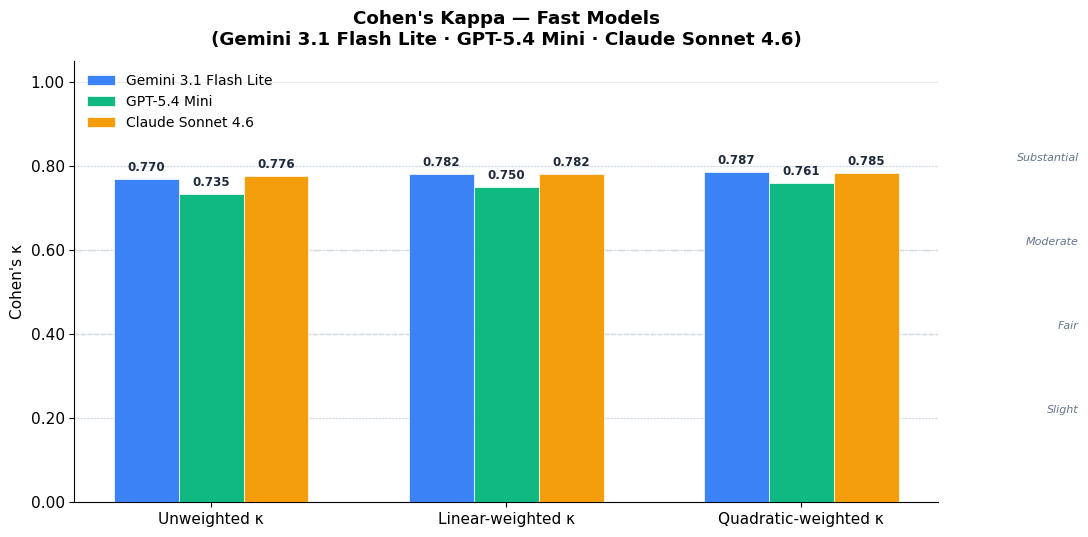

Saved cohens_kappa_flash_models.png


In [20]:
# ── Kappa visualization — Flash models ───────────────────────────────────────
ORANGE = '#F59E0B'  # Claude

fast_kappa = kappa_df[kappa_df['Tier'] == 'Fast'].reset_index(drop=True)

kappa_metrics = ["Cohen's \u03ba", 'Linear-weighted \u03ba', 'Quadratic-weighted \u03ba']
kappa_labels  = ['Unweighted \u03ba', 'Linear-weighted \u03ba', 'Quadratic-weighted \u03ba']
fast_colors   = [BLUE, GREEN, ORANGE]

x     = np.arange(len(kappa_metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

n_models = len(fast_kappa)
for i, (_, row) in enumerate(fast_kappa.iterrows()):
    vals   = [row[m] for m in kappa_metrics]
    offset = (i - (n_models - 1) / 2) * width
    bars   = ax.bar(x + offset, vals, width, label=row['Model'],
                    color=fast_colors[i], edgecolor='white', linewidth=0.5, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                color='#1E293B')

# Landis-Koch tier reference lines
tiers = [(0.20, 'Slight', ':'), (0.40, 'Fair', '--'),
         (0.60, 'Moderate', '-.'), (0.80, 'Substantial', ':')]
for y, label, ls in tiers:
    ax.axhline(y, color='#94A3B8', linestyle=ls, linewidth=0.9, zorder=1)
    ax.text(len(kappa_metrics) - 0.06, y + 0.008, label,
            ha='right', va='bottom', fontsize=8, color='#64748B', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(kappa_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cohen's \u03ba", fontsize=11)
ax.set_title(f"Cohen's Kappa — Fast Models\n({FAST_A_NAME} · {FAST_B_NAME} · {FAST_C_NAME})",
             fontweight='bold', pad=12)
ax.legend(loc='upper left', frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', color='#E2E8F0', linewidth=0.6, zorder=0)

plt.tight_layout()
plt.savefig('cohens_kappa_flash_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved cohens_kappa_flash_models.png")

In [21]:
# ── Cell 2: Wilson 95% confidence intervals on per-bucket recall ───────────────
# Recall on a bucket = (# correctly predicted) / (# truly in that bucket).
# With small per-bucket sample sizes, a point estimate is misleading. Wilson
# score intervals give a proper 95% CI for a binomial proportion and behave
# well even when n is small or recall is near 0/1 (unlike normal-approx).

from statsmodels.stats.proportion import proportion_confint

ALL_MODELS = [
    ('Pro',  'Gemini 3.1 Pro',         m_gemini),
    ('Pro',  'GPT-5.4',                m_gpt),
    ('Pro',  'Claude Opus 4.6',        m_claude),
    ('Fast', 'Gemini 3.1 Flash Lite',  m_gemini_f),
    ('Fast', 'GPT-5.4 Mini',           m_gpt_f),
    ('Fast', 'Claude Sonnet 4.6',      m_claude_f),
]

def ci_rows(tier, name, df):
    out = []
    for lbl in LABEL_ORDER:
        n_true = int((df['true_label'] == lbl).sum())
        n_correct = int(((df['true_label'] == lbl) & (df['pred_label'] == lbl)).sum())
        if n_true == 0:
            recall, lo, hi = float('nan'), float('nan'), float('nan')
        else:
            recall = n_correct / n_true
            lo, hi = proportion_confint(n_correct, n_true, alpha=0.05, method='wilson')
        out.append({
            'Tier': tier,
            'Model': name,
            'Bucket': lbl,
            'n': n_true,
            'Correct': n_correct,
            'Recall': f'{recall:.1%}' if n_true else 'n/a',
            '95% CI': f'[{lo:.1%}, {hi:.1%}]' if n_true else 'n/a',
            'CI width': f'{(hi - lo):.1%}' if n_true else 'n/a',
        })
    # Overall recall (== accuracy across all rows)
    n = len(df)
    c = int((df['true_label'] == df['pred_label']).sum())
    lo, hi = proportion_confint(c, n, alpha=0.05, method='wilson')
    out.append({
        'Tier': tier,
        'Model': name,
        'Bucket': 'OVERALL',
        'n': n,
        'Correct': c,
        'Recall': f'{c/n:.1%}',
        '95% CI': f'[{lo:.1%}, {hi:.1%}]',
        'CI width': f'{(hi - lo):.1%}',
    })
    return out

all_rows = []
for tier, name, df in ALL_MODELS:
    all_rows.extend(ci_rows(tier, name, df))

ci_df = pd.DataFrame(all_rows)
print('Wilson 95% confidence intervals on recall')
print('=' * 90)
for tier in ['Pro', 'Fast']:
    print(f'\n── {tier} models ' + '─' * 70)
    sub = ci_df[ci_df['Tier'] == tier].drop(columns=['Tier'])
    print(sub.to_string(index=False))
print()
print('Read this as: the true long-run recall on this bucket is plausibly anywhere')
print('inside the 95% CI. Wide intervals = small n in that bucket — be cautious')
print('about ranking models on buckets where the intervals overlap heavily.')

Wilson 95% confidence intervals on recall

── Pro models ──────────────────────────────────────────────────────────────────────
          Model               Bucket   n  Correct Recall         95% CI CI width
 Gemini 3.1 Pro               Oppose 101       85  84.2% [75.8%, 90.0%]    14.2%
 Gemini 3.1 Pro              Neutral  47       35  74.5% [60.5%, 84.7%]    24.3%
 Gemini 3.1 Pro              Support  47       34  72.3% [58.2%, 83.1%]    24.8%
 Gemini 3.1 Pro Support with Changes  39       33  84.6% [70.3%, 92.8%]    22.5%
 Gemini 3.1 Pro              OVERALL 234      187  79.9% [74.3%, 84.5%]    10.2%
        GPT-5.4               Oppose 101       63  62.4% [52.6%, 71.2%]    18.6%
        GPT-5.4              Neutral  47       39  83.0% [69.9%, 91.1%]    21.3%
        GPT-5.4              Support  47       29  61.7% [47.4%, 74.2%]    26.8%
        GPT-5.4 Support with Changes  39       29  74.4% [58.9%, 85.4%]    26.5%
        GPT-5.4              OVERALL 234      160  68.4% [62.2

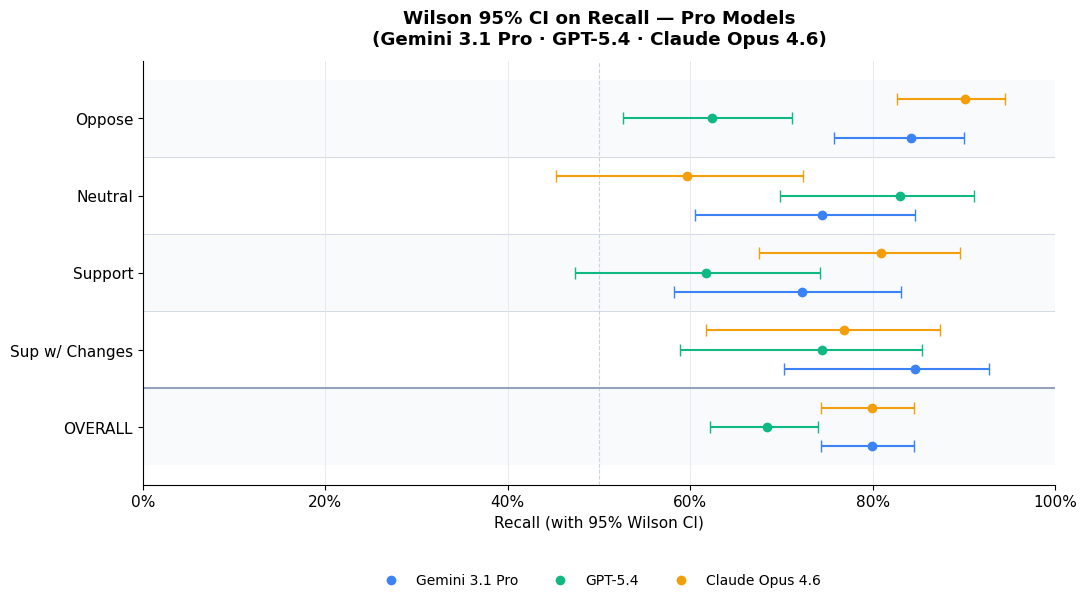

Saved recall_ci_pro_models.png


In [22]:
# ── CI visualization — Pro models (forest plot) ───────────────────────────────
ORANGE = '#F59E0B'  # Claude

pro_ci = ci_df[ci_df['Tier'] == 'Pro'].copy()
pro_models_list = pro_ci['Model'].unique().tolist()
buckets_order = LABEL_ORDER + ['OVERALL']
pro_model_colors = {m: c for m, c in zip(pro_models_list, [BLUE, GREEN, ORANGE])}

bucket_labels = {
    'Oppose': 'Oppose',
    'Neutral': 'Neutral',
    'Support': 'Support',
    'Support with Changes': 'Sup w/ Changes',
    'OVERALL': 'OVERALL',
}

def parse_recall(s):
    try:
        return float(str(s).strip('%')) / 100
    except:
        return float('nan')

def parse_ci(s):
    try:
        s = str(s).strip('[]')
        lo, hi = s.split(',')
        return float(lo.strip('% ')) / 100, float(hi.strip('% ')) / 100
    except:
        return float('nan'), float('nan')

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

n_models = len(pro_models_list)
offsets  = np.linspace(-0.25, 0.25, n_models)
y_pos = {b: i for i, b in enumerate(reversed(buckets_order))}

for model, offset in zip(pro_models_list, offsets):
    color = pro_model_colors[model]
    model_rows = pro_ci[pro_ci['Model'] == model]
    for _, row in model_rows.iterrows():
        b = row['Bucket']
        if b not in y_pos:
            continue
        recall = parse_recall(row['Recall'])
        lo, hi = parse_ci(row['95% CI'])
        y      = y_pos[b] + offset
        if not (recall != recall):
            ax.errorbar(recall, y, xerr=[[recall - lo], [hi - recall]],
                        fmt='o', color=color, ecolor=color, capsize=4,
                        markersize=6, linewidth=1.5, zorder=3)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                      markersize=8, label=m) for m, c in zip(pro_models_list, [BLUE, GREEN, ORANGE])]
ax.legend(handles=handles, frameon=False, fontsize=10,
          loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=n_models)

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels([bucket_labels.get(b, b) for b in reversed(buckets_order)], fontsize=11)
ax.set_xlabel('Recall (with 95% Wilson CI)', fontsize=11)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.axvline(0.5, color='#CBD5E1', linewidth=0.8, linestyle='--', zorder=1)

ax.set_title(f"Wilson 95% CI on Recall — Pro Models\n({PRO_A_NAME} · {PRO_B_NAME} · {PRO_C_NAME})",
             fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, b in enumerate(reversed(buckets_order)):
    color_band = '#F8FAFC' if i % 2 == 0 else 'white'
    ax.axhspan(i - 0.5, i + 0.5, facecolor=color_band, zorder=0)

for i in range(len(buckets_order) - 1):
    ax.axhline(i + 0.5, color='#CBD5E1', linewidth=0.6, linestyle='-', zorder=1)

ax.axhline(0.5, color='#94A3B8', linewidth=1.5, zorder=2)
ax.grid(axis='x', color='#E2E8F0', linewidth=0.6, zorder=1)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig('recall_ci_pro_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved recall_ci_pro_models.png")

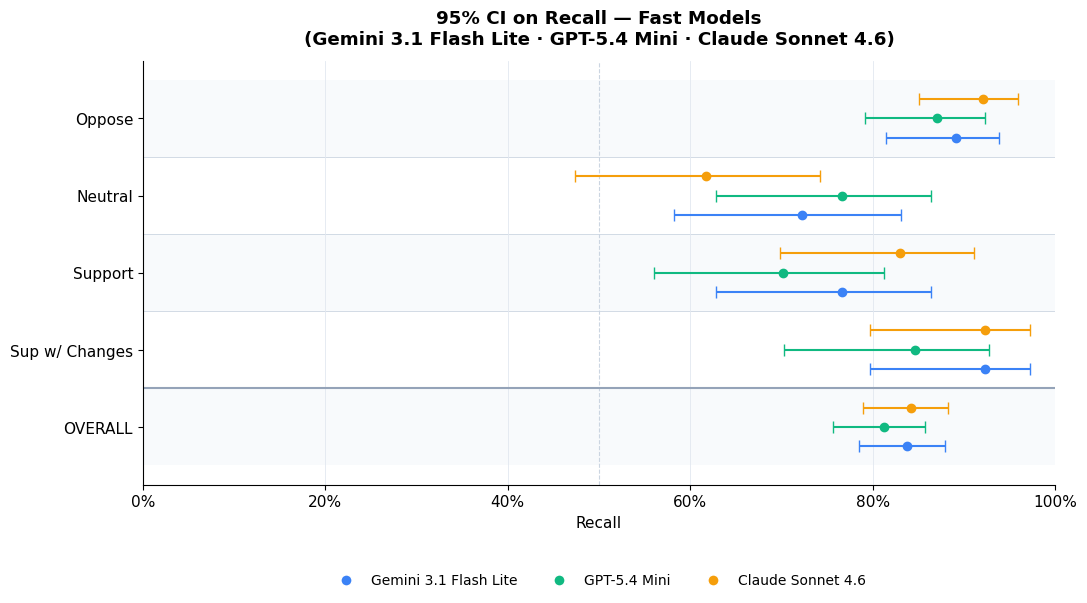

Saved recall_ci_flash_models.png


In [23]:
# ── CI visualization — Flash models (forest plot) ─────────────────────────────
ORANGE = '#F59E0B'  # Claude

fast_ci = ci_df[ci_df['Tier'] == 'Fast'].copy()
fast_models_list = fast_ci['Model'].unique().tolist()
fast_model_colors = {m: c for m, c in zip(fast_models_list, [BLUE, GREEN, ORANGE])}

buckets_order = LABEL_ORDER + ['OVERALL']
bucket_labels = {
    'Oppose': 'Oppose',
    'Neutral': 'Neutral',
    'Support': 'Support',
    'Support with Changes': 'Sup w/ Changes',
    'OVERALL': 'OVERALL',
}

def parse_recall(s):
    try:
        return float(str(s).strip('%')) / 100
    except:
        return float('nan')

def parse_ci(s):
    try:
        s = str(s).strip('[]')
        lo, hi = s.split(',')
        return float(lo.strip('% ')) / 100, float(hi.strip('% ')) / 100
    except:
        return float('nan'), float('nan')

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

n_models = len(fast_models_list)
offsets  = np.linspace(-0.25, 0.25, n_models)

y_pos = {b: i for i, b in enumerate(reversed(buckets_order))}

for model, offset in zip(fast_models_list, offsets):
    color = fast_model_colors[model]
    model_rows = fast_ci[fast_ci['Model'] == model]
    for _, row in model_rows.iterrows():
        b = row['Bucket']
        if b not in y_pos:
            continue
        recall  = parse_recall(row['Recall'])
        lo, hi  = parse_ci(row['95% CI'])
        y       = y_pos[b] + offset
        if not (recall != recall):
            ax.errorbar(recall, y, xerr=[[recall - lo], [hi - recall]],
                        fmt='o', color=color, ecolor=color, capsize=4,
                        markersize=6, linewidth=1.5, zorder=3)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
           markersize=8, label=m) for m, c in zip(fast_models_list, [BLUE, GREEN, ORANGE])]
ax.legend(handles=handles, frameon=False, fontsize=10,
          loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=n_models)
ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels([bucket_labels.get(b, b) for b in reversed(buckets_order)], fontsize=11)
ax.set_xlabel('Recall', fontsize=11)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.axvline(0.5, color='#CBD5E1', linewidth=0.8, linestyle='--', zorder=1)

ax.set_title(f"95% CI on Recall — Fast Models\n({FAST_A_NAME} · {FAST_B_NAME} · {FAST_C_NAME})",
             fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, b in enumerate(reversed(buckets_order)):
    color_band = '#F8FAFC' if i % 2 == 0 else 'white'
    ax.axhspan(i - 0.5, i + 0.5, facecolor=color_band, zorder=0)

for i in range(len(buckets_order) - 1):
    ax.axhline(i + 0.5, color='#CBD5E1', linewidth=0.6, linestyle='-', zorder=1)

ax.axhline(0.5, color='#94A3B8', linewidth=1.5, zorder=2)
ax.grid(axis='x', color='#E2E8F0', linewidth=0.6, zorder=1)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig('recall_ci_flash_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved recall_ci_flash_models.png")